In [2]:
import numpy as np 

# Pour l'affichage des performances
import matplotlib.pyplot as plt 
from matplotlib import cm
import seaborn as sns
import itertools

# Pour les performances de classification
from sklearn.metrics import classification_report, confusion_matrix 

# Pour charger le dataset MNIST
from tensorflow.keras.datasets.mnist import load_data 

# Pour instancier et entraîner un modèle Random Forest
from sklearn.ensemble import RandomForestClassifier

# Pour créer des itérateurs
import itertools 


In [4]:
import os
import numpy as np
from keras.utils import load_img, img_to_array

def load_dataset_from_directory(base_dir, img_size, color_mode):
    X = []
    y = []
    class_names = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        class_index = len(class_names) - 1

        for root, dirs, files in os.walk(class_path):
            for filename in files:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    file_path = os.path.join(root, filename)

                    img = load_img(file_path, target_size=img_size, color_mode=color_mode)
                    img_array = img_to_array(img)

                    X.append(img_array)
                    y.append(class_index)

    return np.array(X), np.array(y), class_names

In [5]:
chemin_good=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Train"
chemin_test=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Test"

In [6]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = chemin_good
test_dir  = chemin_test

img_size = (128, 128)   # 
color_mode = "rgb"  # ou "grayscale"

In [7]:
X_train, y_train, class_names_train = load_dataset_from_directory(train_dir, img_size, color_mode)

In [8]:
X_test, y_test, class_names_test = load_dataset_from_directory(test_dir, img_size, color_mode)

In [9]:
# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)

Shape of X: (5865, 128, 128, 3)
Shape of y: (5865,)


In [10]:
# Changer la forme de X_train et X_test
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)

Shape of X: (5865, 49152)
Shape of y: (5865,)


In [11]:
model = RandomForestClassifier(n_jobs=-1)

In [12]:
model.fit(X_train, y_train);


In [13]:
# Prédiction sur l'échantillon de test
test_pred = model.predict(X_test)

# Performance du modèle
model.score(X_test, y_test)


0.9727536231884057

In [14]:
print("Evaluation détaillée de la Classification par RDF :\n \n" ,
      (classification_report(y_test, test_pred)))

Evaluation détaillée de la Classification par RDF :
 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       0.97      1.00      0.98       117
           4       0.70      0.79      0.75        78
           5       1.00      1.00      1.00       110
           6       0.98      1.00      0.99       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       1.00      1.00      1.00       160
          10       0.86      0.79      0.82       117
          11       1.00      1.00      1.00        42
          12       1.00      0.94      0.97       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           0.97      1725
   macro avg       0.97  

In [55]:
import pandas as pd
report = classification_report(
    y_test,
    test_pred,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose().round(3)

print(df_report)
num_cat=0
print(f"nombre de valeurs dans la catégorie {num_cat} :",df_report.iloc[num_cat,3])



              precision  recall  f1-score   support
0                 1.000   1.000     1.000    83.000
1                 1.000   1.000     1.000   150.000
2                 1.000   1.000     1.000   132.000
3                 0.967   1.000     0.983   117.000
4                 0.705   0.795     0.747    78.000
5                 1.000   1.000     1.000   110.000
6                 0.984   1.000     0.992   124.000
7                 1.000   1.000     1.000   115.000
8                 1.000   1.000     1.000   167.000
9                 1.000   1.000     1.000   160.000
10                0.860   0.786     0.821   117.000
11                1.000   1.000     1.000    42.000
12                1.000   0.940     0.969   100.000
13                1.000   1.000     1.000    79.000
14                1.000   1.000     1.000   151.000
accuracy          0.973   0.973     0.973     0.973
macro avg         0.968   0.968     0.968  1725.000
weighted avg      0.974   0.973     0.973  1725.000
nombre de va

Nombre de mal catégorisés : 47


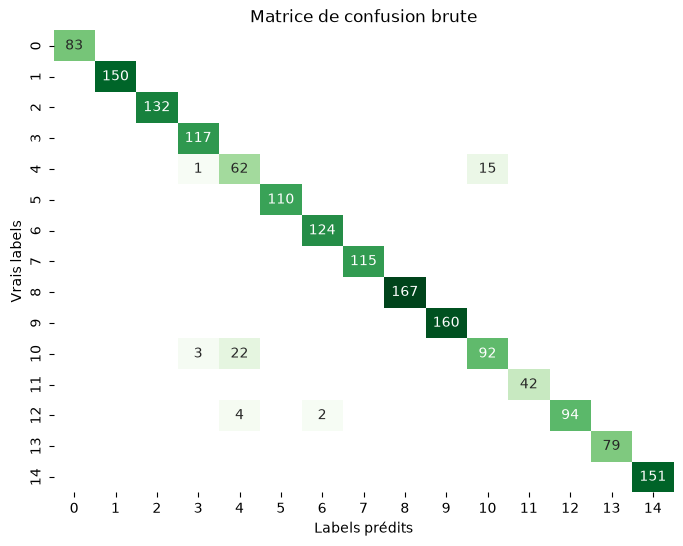

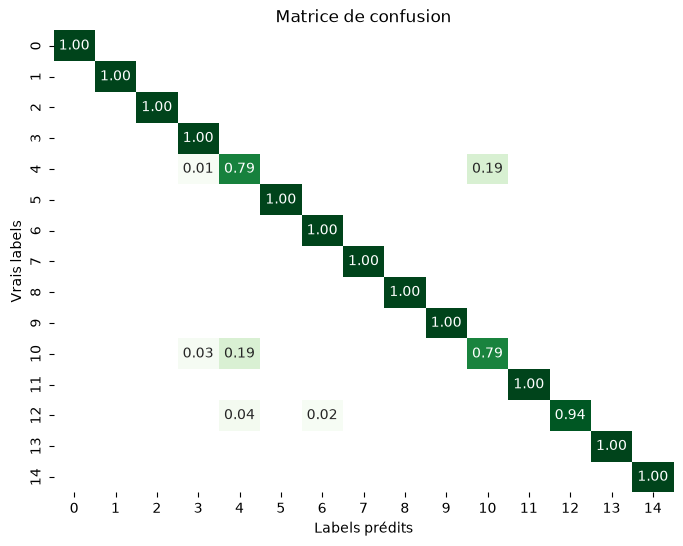

In [78]:
# Calculer la matrice de confusion
cnf_matrix_brute = confusion_matrix(y_test, test_pred, normalize=None)
mask_brute=(cnf_matrix_brute == 0)
mask_norm=(cnf_matrix == 0)
cnf_matrix = confusion_matrix(y_test, test_pred, normalize='true')


nb_erreurs = cnf_matrix_brute.sum() - np.trace(cnf_matrix_brute)
print("Nombre de mal catégorisés :", nb_erreurs)

# Tracer la heatmap de la matrice de confusion brute
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion brute")
sns.heatmap(cnf_matrix_brute, mask=mask_brute, cmap='Greens', annot=True, cbar=False, fmt=".0f")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion")
sns.heatmap(cnf_matrix, mask=mask_norm, cmap='Greens', annot=True, cbar=False, fmt=".2f")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [80]:
for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    if cnf_matrix[i, j] > 0.000 and i != j:  # Seuil de 0.0% pour les erreurs significatives
        print(f"{cnf_matrix[i, j] * 100:.2f}% des instances de la catégorie {i} ont été classées comme {j}.")


1.28% des instances de la catégorie 4 ont été classées comme 3.
19.23% des instances de la catégorie 4 ont été classées comme 10.
2.56% des instances de la catégorie 10 ont été classées comme 3.
18.80% des instances de la catégorie 10 ont été classées comme 4.
4.00% des instances de la catégorie 12 ont été classées comme 4.
2.00% des instances de la catégorie 12 ont été classées comme 6.


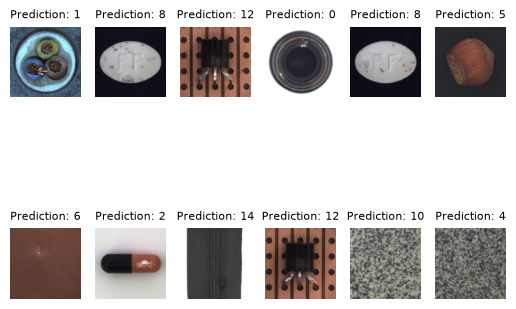

In [81]:
j = 1

for i in np.random.choice(np.arange(0, len(y_test)), size=12):
    img = X_test[i] 
    
    # Redimensionnement de l'image
    img = img.reshape(128, 128,3).astype(np.uint8)
    
    # Sélection de la sous-figure
    plt.subplot(2, 6, j)
    j = j + 1
    
    # Suppression des axes
    plt.axis('off')
    
    # Affichage de l'image en niveaux de gris
    plt.imshow(img, cmap = cm.binary)
    plt.title('Prediction: ' + str(test_pred[i]),fontsize=8)


47
[482, 494, 496, 503, 506, 510, 511, 512, 515, 516, 523, 524, 525, 544, 553, 556, 1236, 1237, 1239, 1250, 1253, 1254, 1270, 1280, 1288, 1298, 1299, 1304, 1305, 1306, 1308, 1311, 1313, 1314, 1318, 1323, 1329, 1330, 1342, 1349, 1351, 1487, 1488, 1489, 1490, 1492, 1493]
1725


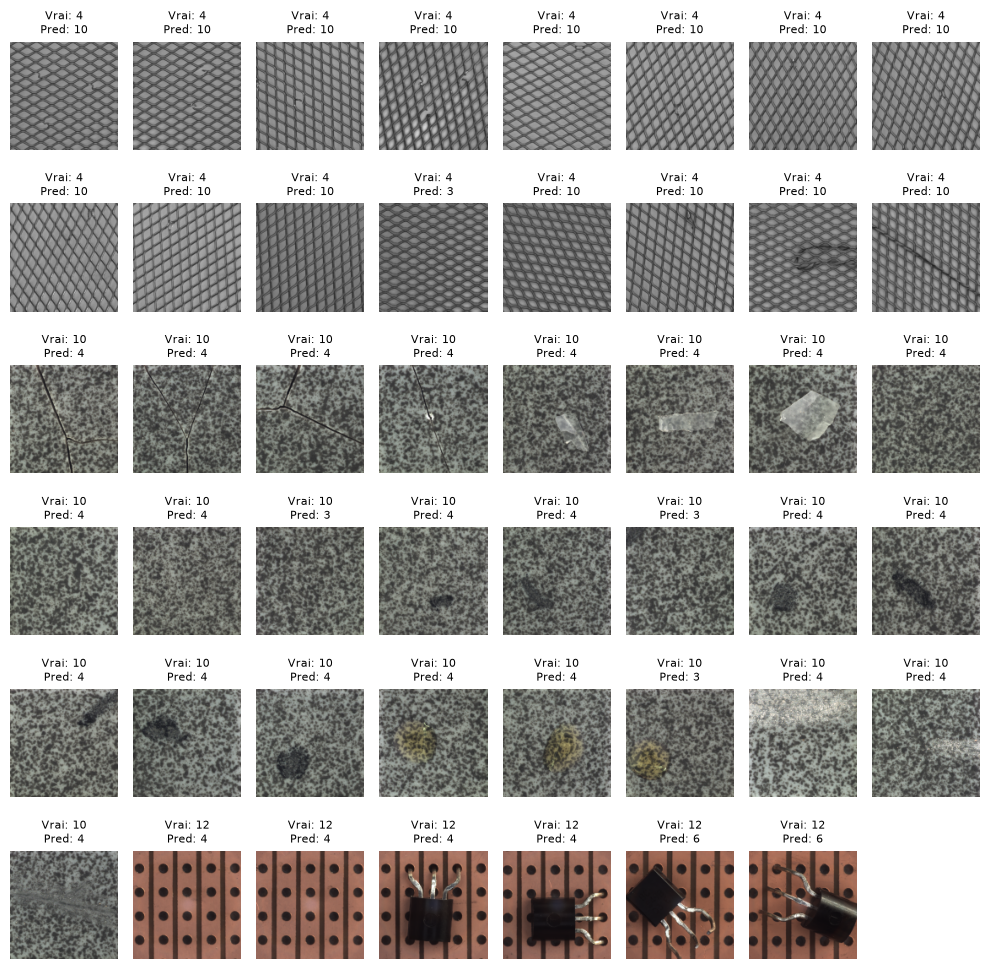

In [97]:
categories = [4, 10, 12]

enr_defauts=[]
for i in range(1,len(y_test)):
        if y_test[i] != test_pred[i]:
            enr_defauts.append(i)
            
print(len(enr_defauts))
print(enr_defauts)
    
    
j = 1
plt.figure(figsize=(10, 10))
y_prec=0
num_sortis=[]
print(len(y_test))
for i in enr_defauts:
    img = X_test[i].reshape(128, 128, 3).astype(np.uint8)

    plt.subplot((nb_erreurs // 8) + 1, 8, j)
    plt.axis('off')
    plt.imshow(img)

    plt.title(
        f"Vrai: {y_test[i]}\nPred: {test_pred[i]}",
        fontsize=8
    )
    
    j += 1

               
plt.tight_layout()
plt.show()